In [18]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage

# Changed import from OpenAI to Groq
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from langgraph.checkpoint.memory import MemorySaver
memory_saver = MemorySaver()

In [19]:
load_dotenv()  # Load environment variables from .env file

True

In [20]:
llm = ChatGroq(model="openai/gpt-oss-20b", temperature=0)

In [21]:
from langgraph.graph.message import add_messages

class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [22]:
# Ensure you have imported ChatGroq:
# from langchain_groq import ChatGroq

llm = ChatGroq(model="openai/gpt-oss-20b")

In [23]:
def chat_node(state: ChatState):
    # take user query from state
    messages = state['messages']
    
    # send to llm
    response = llm.invoke(messages)
    
    # response store state
    return {'messages': [response]}

graph = StateGraph(ChatState)

In [24]:
checkpoint = MemorySaver()

graph = StateGraph(ChatState)

# add nodes
graph.add_node('chat_node', chat_node)

# add edges
graph.add_edge(START, 'chat_node')
graph.add_edge('chat_node', END)

chatbot = graph.compile(checkpointer=memory_saver)

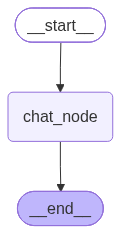

In [25]:
chatbot 

In [36]:
thread_id = "1"
initial_state = {
    'messages': [HumanMessage(content='What is my name? ')]
}

config = {'configurable': {'thread_id': thread_id}}  

response = chatbot.invoke(initial_state, config=config)  # ⬅️ Pass config here
print(response['messages'][-1].content)

Your name is Poppi.


In [31]:
response['messages'][-1].content

'Got it—your name is Poppi. How can I help you today?'

In [37]:
chatbot.get_state(config=config)

StateSnapshot(values={'messages': [HumanMessage(content='hi', additional_kwargs={}, response_metadata={}, id='796d1f63-f700-4494-a68f-d2a3a5ced2ef'), AIMessage(content='Hello! How can I help you today?', additional_kwargs={'reasoning_content': 'The user says "hi". We should respond politely. Possibly ask how can I help.'}, response_metadata={'token_usage': {'completion_tokens': 37, 'prompt_tokens': 72, 'total_tokens': 109, 'completion_time': 0.061330607, 'completion_tokens_details': {'reasoning_tokens': 19}, 'prompt_time': 0.00364823, 'prompt_tokens_details': None, 'queue_time': 0.211665471, 'total_time': 0.064978837}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_a12402de73', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0eaff-52c9-71c3-8c27-9bf1e0db5f41-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 72, 'output_tokens': 37, 'total_tokens': 109, 'output_token_details': {'reas

In [29]:


thread_id = "1"

while True:
    user_message = input('Type here: ')
    print('User:', user_message)
    
    if user_message.strip().lower() in ['exit', 'quit', 'bye']:
        print("Goodbye!")
        break
    
    # 1. Define the config
    config = {'configurable': {'thread_id': thread_id}}
    
    # 2. Pass the input AND config correctly to .invoke()
    response = chatbot.invoke(
        {'messages': [HumanMessage(content=user_message)]}, 
        config=config
    )
    
    # 3. Print the actual AI response
    print('AI:', response['messages'][-1].content)

User: hi
AI: Hello! How can I help you today?
User: my name is poppi
AI: Nice to meet you, Poppi! How can I help you today?
User: what is your name?
AI: I’m ChatGPT, an AI language model created by OpenAI. How can I help you today?
User: ok, what is Anaconda?
AI: **Anaconda** is a free and open‑source distribution of the Python (and R) programming languages that’s especially popular in data science, machine learning, and scientific computing. It bundles:

| What it is | Why it matters |
|------------|----------------|
| **Python & R installers** | You can use either language without having to install them separately. |
| **Conda package manager** | Installs, updates, and removes software packages (and their dependencies) in isolated “environments.”  Conda can also handle non‑Python libraries (e.g., C/C++ binaries). |
| **Pre‑built scientific libraries** | Packages like NumPy, pandas, SciPy, scikit‑learn, TensorFlow, PyTorch, matplotlib, Jupyter, etc., are included out‑of‑the‑box, so yo